# Download BHNSs (NSBH) Population Synthesis Data & Build Combined BNS+NSBH Sampler

This notebook:
1. **Downloads** BHNSs (NSBH) Merger Rate Density files from [iogiul/iorio22_plot](https://gitlab.com/iogiul/iorio22_plot) (v3 branch)
2. **Organises** them alongside existing BNS data under `datafiles/populations/MRD/`
3. **Compares** BNS vs BHNSs merger rates
4. **Generates** redshift samples for the combined BNS+NSBH model
5. **Demonstrates** the `src.nsbh` module: combined Monte Carlo with tunable NSBH fraction and viewing-angle parameter

**Goal**: Explore the BNS rate deficit by injecting a controllable fraction of NSBH-origin GRBs with a free jet viewing-angle parameter `theta_nsbh_max`.

In [12]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from pathlib import Path
from astropy.cosmology import Planck18 as Planck
from itertools import product
import requests
import urllib.parse
import json
import sys

sys.path.insert(0, '..')
plt.style.use('../configurations/style.mplstyle')

# Paths
datafiles  = Path("../datafiles")
mrd_base   = datafiles / "populations" / "MRD"
sample_dir = datafiles / "populations" / "samples"

# GitLab parameters
PROJECT    = "iogiul/iorio22_plot"
BRANCH     = "v3"
BASE_PATH  = "Merger_rate/cosmo_rate_bavera"
POP_FILE   = "MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat"
ALPHA_VALS = ["A0.5", "A1.0", "A3.0", "A5.0"]

print("Setup complete.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setup complete.


## 1. Discover BHNSs MRD Files from GitLab API

Use the GitLab REST API to recursively list all MRD files under `BHNSs/` directories.

In [13]:
project_id = urllib.parse.quote(PROJECT, safe='')
api_url = f"https://gitlab.com/api/v4/projects/{project_id}/repository/tree"

params_req = {'ref': BRANCH, 'path': BASE_PATH, 'per_page': 2000, 'recursive': True}
response = requests.get(api_url, params=params_req)
if response.status_code != 200:
    raise Exception(f"Error: {response.status_code} - {response.text}")
entries = response.json()

mrd_files = []
for entry in entries:
    if entry["type"] == "tree":
        subdir = entry["path"]
        page = 1
        while True:
            params_sub = {'ref': BRANCH, 'path': subdir, 'per_page': 2000, 'page': page}
            sub_response = requests.get(api_url, params=params_sub)
            if sub_response.status_code != 200:
                break
            sub_entries = sub_response.json()
            if not sub_entries:
                break
            for item in sub_entries:
                if item["type"] == "blob" and item["name"].startswith("MRD"):
                    mrd_files.append(item["path"])
            page += 1
    elif entry["type"] == "blob" and entry["name"].startswith("MRD"):
        mrd_files.append(entry["path"])

bhns_files = [f for f in mrd_files if "/BHNSs/" in f]
print(f"Found {len(bhns_files)} BHNSs MRD files:")
for f in bhns_files[:10]:
    print(f"  {f}")
if len(bhns_files) > 10:
    print(f"  ... and {len(bhns_files) - 10} more") 

Found 384 BHNSs MRD files:
  Merger_rate/cosmo_rate_bavera/output_sigma0.1/fiducial_HGoptimistic/A0.5/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  Merger_rate/cosmo_rate_bavera/output_sigma0.1/fiducial_HGoptimistic/A1.0/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  Merger_rate/cosmo_rate_bavera/output_sigma0.1/fiducial_HGoptimistic/A3.0/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  Merger_rate/cosmo_rate_bavera/output_sigma0.1/fiducial_HGoptimistic/A5.0/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  Merger_rate/cosmo_rate_bavera/output_sigma0.1/fiducial_Hrad/A0.5/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  Merger_rate/cosmo_rate_bavera/output_sigma0.1/fiducial_Hrad/A1.0/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  Merger_rate/cosmo_rate_bavera/output_sigma0.1/fiducial_Hrad/A3.0/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  Merger_rate/cosmo_rate_bavera/output_sigma0.1/fiducial_Hrad/A5.0/BHNSs/MRD_spread_15Z_40_No_MandF20

## 2. Download BHNSs MRD Files

Download only `/BHNSs/` files, preserving the directory structure under `datafiles/populations/MRD/`. Skips files that already exist locally.

In [3]:
save_dir = mrd_base
save_dir.mkdir(parents=True, exist_ok=True)
base_raw_url = f"https://gitlab.com/{PROJECT}/-/raw/{BRANCH}/"

downloaded, skipped = 0, 0
for repo_file in bhns_files:
    try:
        relative_path = Path(repo_file).relative_to(BASE_PATH)
    except ValueError:
        relative_path = Path(repo_file)
    local_file = save_dir / relative_path
    
    if local_file.exists():
        skipped += 1
        continue
    
    raw_url = f"{base_raw_url}{repo_file}"
    resp = requests.get(raw_url)
    if resp.status_code == 200:
        local_file.parent.mkdir(parents=True, exist_ok=True)
        with open(local_file, 'wb') as f:
            f.write(resp.content)
        downloaded += 1
        print(f"  Saved {local_file.relative_to(save_dir)}")
    else:
        print(f"  FAILED ({resp.status_code}): {relative_path}")

print(f"\nDone: {downloaded} downloaded, {skipped} already existed.")

  Saved output_sigma0.1/fiducial_HGoptimistic/A0.5/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  Saved output_sigma0.1/fiducial_HGoptimistic/A1.0/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  Saved output_sigma0.1/fiducial_HGoptimistic/A3.0/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  Saved output_sigma0.1/fiducial_HGoptimistic/A5.0/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  Saved output_sigma0.1/fiducial_Hrad/A0.5/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  Saved output_sigma0.1/fiducial_Hrad/A1.0/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  Saved output_sigma0.1/fiducial_Hrad/A3.0/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  Saved output_sigma0.1/fiducial_Hrad/A5.0/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  Saved output_sigma0.1/fiducial_Hrad_5M/A0.5/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  Saved output_sigma0.1/fiducial_Hrad_5M/A1.0/BHNSs/MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  

## 3. Extract BHNSs Files into Flat Structure

Copy BHNSs `.dat` files into `datafiles/populations/MRD/extracted/` with a flat naming convention, paralleling the existing BNSs extraction.

In [4]:
import shutil

source_dir = mrd_base / "output_sigma0.1"
dest_dir   = mrd_base / "extracted"
dest_dir.mkdir(parents=True, exist_ok=True)

for dat_file in source_dir.rglob("*.dat"):
    if "/BHNSs/" in dat_file.as_posix():
        bnss_dir     = dat_file.parent       # BHNSs
        A_folder     = bnss_dir.parent       # e.g. A0.5
        model_folder = A_folder.parent       # e.g. fiducial_delayed
        
        new_name = f"{model_folder.name}_{A_folder.name}_BHNSs_{dat_file.name}"
        new_file = dest_dir / new_name
        shutil.copy2(dat_file, new_file)
        print(f"  {new_name}")

  fiducial_delayed_A0.5_BHNSs_MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  fiducial_delayed_A1.0_BHNSs_MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  fiducial_delayed_A3.0_BHNSs_MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  fiducial_delayed_A5.0_BHNSs_MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  fiducial_fmtbse_A0.5_BHNSs_MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  fiducial_fmtbse_A1.0_BHNSs_MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  fiducial_fmtbse_A3.0_BHNSs_MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  fiducial_fmtbse_A5.0_BHNSs_MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  fiducial_HGoptimistic_A0.5_BHNSs_MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  fiducial_HGoptimistic_A1.0_BHNSs_MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  fiducial_HGoptimistic_A3.0_BHNSs_MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  fiducial_HGoptimistic_A5.0_BHNSs_MRD_spread_15Z_40_No_MandF2017_0.1_No_No_0.dat
  fiducial_Hrad_A0.5_BHNSs_MRD_spread_15Z_40_No_MandF2017_0.

## 4. Compare BNS vs BHNSs Merger Rate Densities

Side-by-side comparison of dN/dz for both populations.

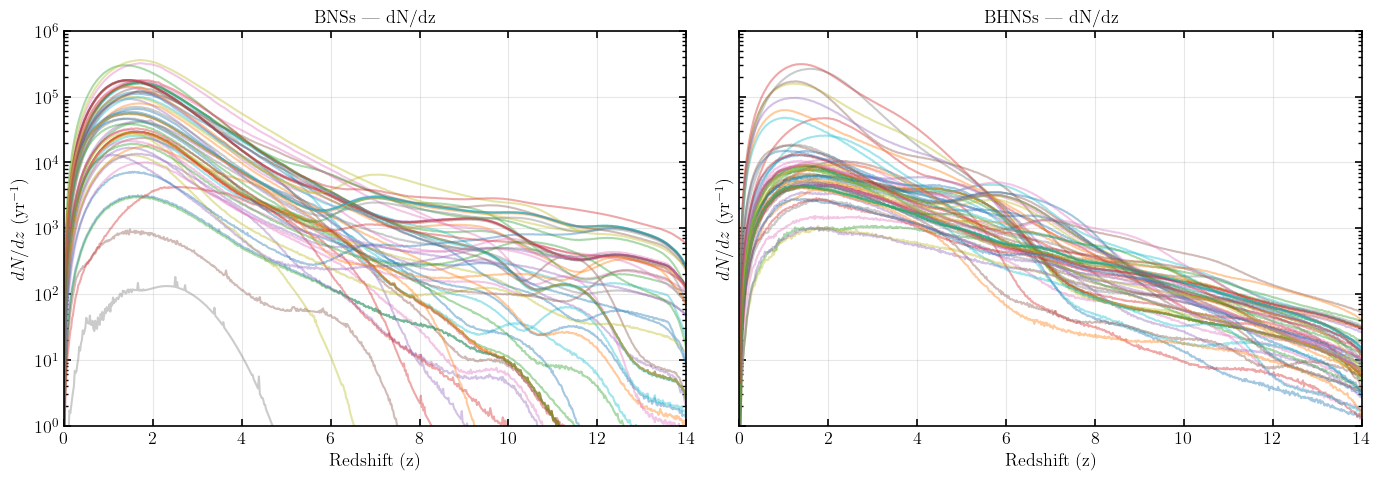

In [9]:
base_mrd    = mrd_base / "output_sigma0.1"
all_folders = sorted(base_mrd.glob("*"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for component, ax in zip(["BNSs", "BHNSs"], axes):
    ax.set_title(f"{component} — dN/dz")
    for alpha, folder in product(ALPHA_VALS, all_folders):
        mrd_file = folder / alpha / component / POP_FILE
        if not mrd_file.exists():
            continue
        z_c, MRD_c = np.loadtxt(mrd_file, unpack=True)
        mrd_vol = 4 * np.pi * Planck.differential_comoving_volume(z_c).to(u.Gpc**3 / u.sr).value
        dN_dz = MRD_c * mrd_vol / (1 + z_c)
        ax.plot(z_c, dN_dz, alpha=0.4)
    ax.set_xlabel("Redshift (z)")
    ax.set_ylabel(r"$dN/dz$ (yr$^{-1}$)")
    ax.set_yscale('log')
    ax.set_xlim(0, 14)
    ax.set_ylim(1, 1e6)
    ax.grid(True)

plt.tight_layout()
plt.show()

## 5. Compute Local Rates and Save to JSON

Compute R₀ (local merger rate at z≈0) for both BNSs and BHNSs across all model/alpha combinations.

In [10]:
from scipy.interpolate import interp1d

local_rates = {}

for alpha in ALPHA_VALS:
    local_rates[alpha] = {}
    for folder in all_folders:
        model = folder.name
        local_rates[alpha][model] = {}
        for component in ["BNSs", "BHNSs"]:
            mrd_file = folder / alpha / component / POP_FILE
            if not mrd_file.exists():
                continue
            z_c, MRD_c = np.loadtxt(mrd_file, unpack=True)
            mrd_interp = interp1d(z_c, MRD_c, kind='linear', fill_value='extrapolate')
            r_0 = float(mrd_interp(0.0))
            local_rates[alpha][model][component] = r_0

# Print summary
print(f"{'Model':<30} {'Alpha':<6} {'BNSs R_0':>12} {'BHNSs R_0':>12} {'Ratio':>8}")
print("=" * 72)
for alpha in ALPHA_VALS:
    for model in sorted(local_rates[alpha]):
        r = local_rates[alpha][model]
        bns_r  = r.get("BNSs", 0)
        bhns_r = r.get("BHNSs", 0)
        ratio  = bhns_r / bns_r if bns_r > 0 else float('nan')
        print(f"{model:<30} {alpha:<6} {bns_r:>12.2f} {bhns_r:>12.2f} {ratio:>8.3f}")

# Save to JSON
with open('calculated_local_rates_combined.json', 'w') as f:
    json.dump(local_rates, f, indent=4)
print("\nSaved to calculated_local_rates_combined.json")

Model                          Alpha      BNSs R_0    BHNSs R_0    Ratio
fiducial_HGoptimistic          A0.5           3.18        35.60   11.188
fiducial_Hrad                  A0.5          23.52        24.74    1.052
fiducial_Hrad_5M               A0.5          23.84        24.33    1.020
fiducial_delayed               A0.5          22.69        35.19    1.551
fiducial_fmtbse                A0.5          15.93        22.76    1.428
fiducial_kick150               A0.5          17.54         7.88    0.449
fiducial_kick265               A0.5           6.27         2.71    0.432
fiducial_klencki               A0.5           0.10       216.27 2157.278
fiducial_l01                   A0.5          13.65       382.83   28.043
fiducial_notides               A0.5          20.57        22.67    1.102
fiducial_notides_pericirc      A0.5          53.49        38.14    0.713
fiducial_pisnfarmer19          A0.5          23.52        24.75    1.052
fiducial_qcbse                 A0.5           2.81 

## 6. Generate BHNSs Redshift Samples

Generate redshift samples from the BHNSs MRD (same pipeline as BNSs) and save alongside existing BNS samples.

In [11]:
from src.redshift import get_mrd_redshift_distribution, sample_from_mrd

sample_dir.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(42)

for folder in sorted(all_folders):
    population = folder.name
    for alpha in ALPHA_VALS:
        for component in ["BHNSs"]:  # BNSs samples already exist
            mrd_file = folder / alpha / component / POP_FILE
            if not mrd_file.exists():
                continue
            
            out_file = sample_dir / f"samples_{population}_{alpha}_{component}_0.dat"
            if out_file.exists():
                print(f"  [skip] {out_file.name}")
                continue
            
            try:
                P_z, total_rate, local_rate, z_grid, P_z_density = get_mrd_redshift_distribution(
                    datafiles=datafiles, population=population,
                    alpha=alpha, component=component
                )
            except FileNotFoundError:
                print(f"  [skip] {population}/{alpha}/{component} — MRD not found")
                continue
            
            n_samples = max(int(total_rate), 100)
            z_samples = sample_from_mrd(P_z, z_grid, P_z_density, n_samples, rng=rng)
            np.savetxt(out_file, z_samples)
            print(f"  {out_file.name}: {n_samples} samples, R_0={local_rate:.1f} Gpc^-3/yr")

print("\nDone generating BHNSs samples.")

  samples_fiducial_HGoptimistic_A0.5_BHNSs_0.dat: 40770 samples, R_0=35.6 Gpc^-3/yr
  samples_fiducial_HGoptimistic_A1.0_BHNSs_0.dat: 38220 samples, R_0=20.7 Gpc^-3/yr
  samples_fiducial_HGoptimistic_A3.0_BHNSs_0.dat: 21328 samples, R_0=16.7 Gpc^-3/yr
  samples_fiducial_HGoptimistic_A5.0_BHNSs_0.dat: 25125 samples, R_0=14.1 Gpc^-3/yr
  samples_fiducial_Hrad_A0.5_BHNSs_0.dat: 30214 samples, R_0=24.7 Gpc^-3/yr
  samples_fiducial_Hrad_A1.0_BHNSs_0.dat: 26818 samples, R_0=14.4 Gpc^-3/yr
  samples_fiducial_Hrad_A3.0_BHNSs_0.dat: 15728 samples, R_0=11.1 Gpc^-3/yr
  samples_fiducial_Hrad_A5.0_BHNSs_0.dat: 14868 samples, R_0=10.5 Gpc^-3/yr
  samples_fiducial_Hrad_5M_A0.5_BHNSs_0.dat: 29531 samples, R_0=24.3 Gpc^-3/yr
  samples_fiducial_Hrad_5M_A1.0_BHNSs_0.dat: 26416 samples, R_0=14.7 Gpc^-3/yr
  samples_fiducial_Hrad_5M_A3.0_BHNSs_0.dat: 15994 samples, R_0=10.7 Gpc^-3/yr
  samples_fiducial_Hrad_5M_A5.0_BHNSs_0.dat: 15189 samples, R_0=10.4 Gpc^-3/yr
  samples_fiducial_delayed_A0.5_BHNSs_0.dat:

## 7. Demonstrate the `src.nsbh` Combined Model (Top-Hat, Lognormal θ_c)

Use the new `src.nsbh` module to initialise a combined BNS+NSBH simulation with the **top-hat** model.

Parameter vector (7-dim):
- `[A_index, L_L0, L_mu_E, sigma_E, theta_c_med_bns, theta_c_med_nsbh, fj_bns]`
- `fj_nsbh` is **fixed** at 0.5 (prefactor, not an MCMC parameter)

In [29]:
from src.nsbh.init import initialize_combined_simulation, NSBHData
from src.top_hat.montecarlo import (
    create_k_interpolator,
    create_geometric_efficiency_lognormal_interpolator,
    compute_luminosity_distance,
)

demo_params = {
    "alpha"         : -0.6,
    "beta_s"        : -2.5,
    "n"             : 2.0,
    "theta_c"       : 3.4,
    "theta_v_max"   : 10.0,
    "z_model"       : "fiducial_Hrad_A1.0",
}

bns_params, nsbh_data, data_dict = initialize_combined_simulation(
    datafiles       = datafiles,
    params          = demo_params,
    size_test       = 2_000,
    nsbh_population = "fiducial_Hrad",
    nsbh_alpha      = "A1.0",
)

# Pre-compute shared objects (once, before MCMC)
k_interpolator  = create_k_interpolator()
geom_eff_interp = create_geometric_efficiency_lognormal_interpolator(sigma_theta_c=0.5)
bns_distances   = compute_luminosity_distance(bns_params.z_arr)

print(f"\nBNS: {len(bns_params.z_arr)} events/yr, z_max={bns_params.z_arr.max():.2f}")
print(f"NSBH: {len(nsbh_data.z_arr)} events/yr, z_max={nsbh_data.z_arr.max():.2f}")
print(f"BHNSs/BNSs rate ratio: {len(nsbh_data.z_arr)/len(bns_params.z_arr):.3f}")

Using redshift model: samples_fiducial_Hrad_A1.0_BNSs_0.dat with 359079 BNSs.
Computed total merger rate: 360832.5 yr^-1 (local R_0 = 112.0 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 26818.1 yr^-1 (local R_0 = 14.4 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_Hrad / A1.0
  BHNSs local rate R_0 = 14.4 Gpc^-3 yr^-1
  BHNSs total rate     = 26818 yr^-1
  1-year z sample size = 26818

BNS: 359079 events/yr, z_max=13.88
NSBH: 26818 events/yr, z_max=14.43
BHNSs/BNSs rate ratio: 0.075


## 8. Visualise BNS vs NSBH Redshift Distributions

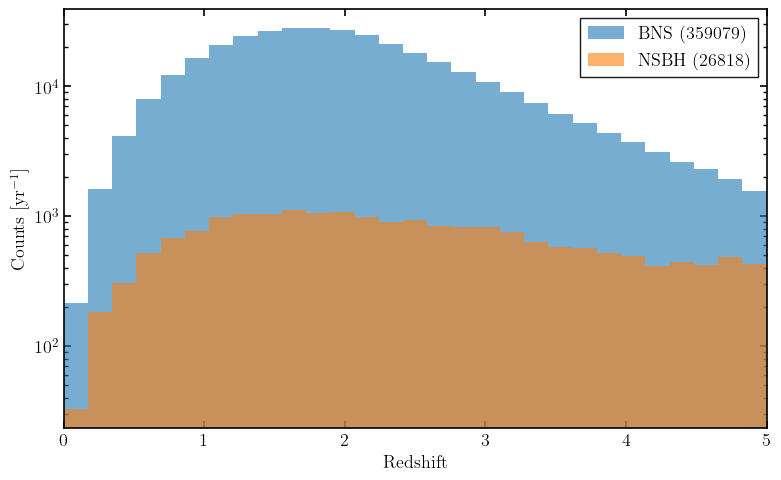

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(0, 5, 30)
ax.hist(bns_params.z_arr, bins=bins, alpha=0.6, label=f"BNS ({len(bns_params.z_arr)})", log=True)
ax.hist(nsbh_data.z_arr, bins=bins, alpha=0.6, label=f"NSBH ({len(nsbh_data.z_arr)})", log=True)
ax.set_xlabel("Redshift")
ax.set_ylabel("Counts $[\\text{yr}^{-1}]$")
ax.legend()
ax.set_xlim(0, 5)

plt.tight_layout()
plt.show()

## 9. Generate Mixed BNS+NSBH Population (Top-Hat, Quick Test)
Use `generate_combined_population_tophat` with the 7-dim parameter vector.

In [40]:
from src.nsbh.montecarlo import generate_combined_population_tophat

# 7-dim: [A_index, L_L0, L_mu_E, sigma_E, theta_c_med_bns, theta_c_med_nsbh, fj_bns]
thetas_test = [2.5, 2.5, 2.7, 0.35, 7.0, 7.0, 0.5]

pop = generate_combined_population_tophat(
    thetas_test, bns_params, nsbh_data,
    k_interpolator, geom_eff_interp,
    n_events=10_000, seed=42,
)

if pop is not None:
    print(f"Total detected: {pop['n_detected']}")
    print(f"  BNS:  {pop['n_bns_det']}")
    print(f"  NSBH: {pop['n_nsbh_det']}")
    print(f"  NSBH fraction of detections: {pop['n_nsbh_det'] / max(pop['n_detected'], 1):.2%}")
else:
    print("No detections (try different parameters).")

Total detected: 1253
  BNS:  709
  NSBH: 544
  NSBH fraction of detections: 43.42%


## 10. MCMC Run — Combined BNS + NSBH (Log-Normal θ_c)

Run `emcee` on the 7-dim parameter vector:

| Index | Parameter | Description |
|-------|-----------|-------------|
| 0 | `A_index` | Luminosity function index |
| 1 | `L_L0` | Luminosity normalisation |
| 2 | `L_mu_E` | Peak energy mean (log₁₀) |
| 3 | `sigma_E` | Peak energy scatter |
| 4 | `theta_c_med_bns` | Median θ_c for BNS (deg) |
| 5 | `theta_c_med_nsbh` | Median θ_c for NSBH (deg) |
| 6 | `fj_bns` | BNS jet-launching fraction |

`fj_nsbh = 0.5` is **fixed** internally and not sampled.

In [43]:
import emcee
from math import inf
from pathlib import Path
import src.init

from src.nsbh.montecarlo import (
    create_log_probability_combined,
    log_likelihood_combined_tophat_ln,
    generate_combined_population_tophat,
    FJ_NSBH_FIXED,
)
from src.top_hat.montecarlo import (
    create_move_strategy,
    run_mcmc,
    check_and_resume_mcmc,
)

# ── Parameters ──────────────────────────────────────────────────────────────
N_PARAMS    = 7
N_WALKERS   = 20
N_STEPS     = 1_000
PARAM_NAMES = [
    r"$k$", r"$\log_{10}(L_0)$", r"$\log_{10}(\mu_E)$", r"$\sigma_E$",
    r"$\theta_{c,\mathrm{med}}^{\mathrm{BNS}}$",
    r"$\theta_{c,\mathrm{med}}^{\mathrm{NSBH}}$",
    r"$f_j^{\mathrm{BNS}}$",
]

# ── Prior ───────────────────────────────────────────────────────────────────
def log_prior_combined(thetas):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_med_bns, theta_c_med_nsbh, fj_bns = thetas

    if not (1.5 < A_index           < 12)  : return -inf
    if not (-2  < L_L0              < 7)   : return -inf
    if not (0.1 < L_mu_E            < 7)   : return -inf
    if not (0   < sigma_E           < 2.5) : return -inf
    if not (1   < theta_c_med_bns   < 25)  : return -inf
    if not (1   < theta_c_med_nsbh  < 25)  : return -inf
    if not (0   < fj_bns            < 10)  : return -inf
    return 0.0

# ── Walker initialisation ──────────────────────────────────────────────────
def initialize_walkers_combined(n_walkers):
    rng = np.random.default_rng(42)
    return np.column_stack([
        rng.uniform(2,   3,    n_walkers),   # A_index
        rng.uniform(2,   4,    n_walkers),   # L_L0
        rng.uniform(2,   4,    n_walkers),   # L_mu_E
        rng.uniform(0.2, 1,    n_walkers),   # sigma_E
        rng.uniform(5,   10,   n_walkers),   # theta_c_med_bns
        rng.uniform(5,   10,   n_walkers),   # theta_c_med_nsbh
        rng.uniform(0.3, 1.5,  n_walkers),   # fj_bns
    ])

# ── Output directory ────────────────────────────────────────────────────────
output_dir = src.init.create_run_dir("NSBH_combined_LN", output_files_default="Output_files")

print(f"N_PARAMS  = {N_PARAMS}")
print(f"N_WALKERS = {N_WALKERS}")
print(f"N_STEPS   = {N_STEPS}")
print(f"fj_nsbh   = {FJ_NSBH_FIXED} (fixed)")
print(f"Output    → {output_dir}")

Creating new directory : Output_files/NSBH_combined_LN
N_PARAMS  = 7
N_WALKERS = 20
N_STEPS   = 1000
fj_nsbh   = 0.5 (fixed)
Output    → Output_files/NSBH_combined_LN


In [80]:
# ── Build log-probability function (closure over data) ──────────────────────
log_probability_combined = create_log_probability_combined(
    log_prior_func  = log_prior_combined,
    bns_params      = bns_params,
    nsbh_data       = nsbh_data,
    k_interpolator  = k_interpolator,
    geom_eff_interp = geom_eff_interp,
    n_events        = 10_000,
)

# ── Resume or start fresh ──────────────────────────────────────────────────
initial_pos, n_steps_remaining, backend = check_and_resume_mcmc(
    filename                = output_dir / "emcee.h5",
    n_steps                 = N_STEPS*20,
    initialize_walkers_func = initialize_walkers_combined,
    n_walkers               = N_WALKERS,
)

# ── Run MCMC ────────────────────────────────────────────────────────────────
sampler = run_mcmc(
    log_probability_func = log_probability_combined,
    initial_walkers      = initial_pos,
    n_iterations         = n_steps_remaining,
    n_walkers            = N_WALKERS,
    n_params             = N_PARAMS,
    backend              = backend,
    blobs_dtype          = [
        ("l_pflux", float),
        ("l_epeak", float),
        ("l_poiss", float),
        ("l_eff",   float),
    ],
)

print(f"\nMCMC complete — {backend.iteration} steps stored.")

Continuing from iteration 10000


100%|██████████| 10000/10000 [13:38<00:00, 12.22it/s]


MCMC complete — 20000 steps stored.


## 11. MCMC Diagnostics

Total steps: 20000
After burn-in (333) + thin (15): 26220 samples
Acceptance fraction: 0.012


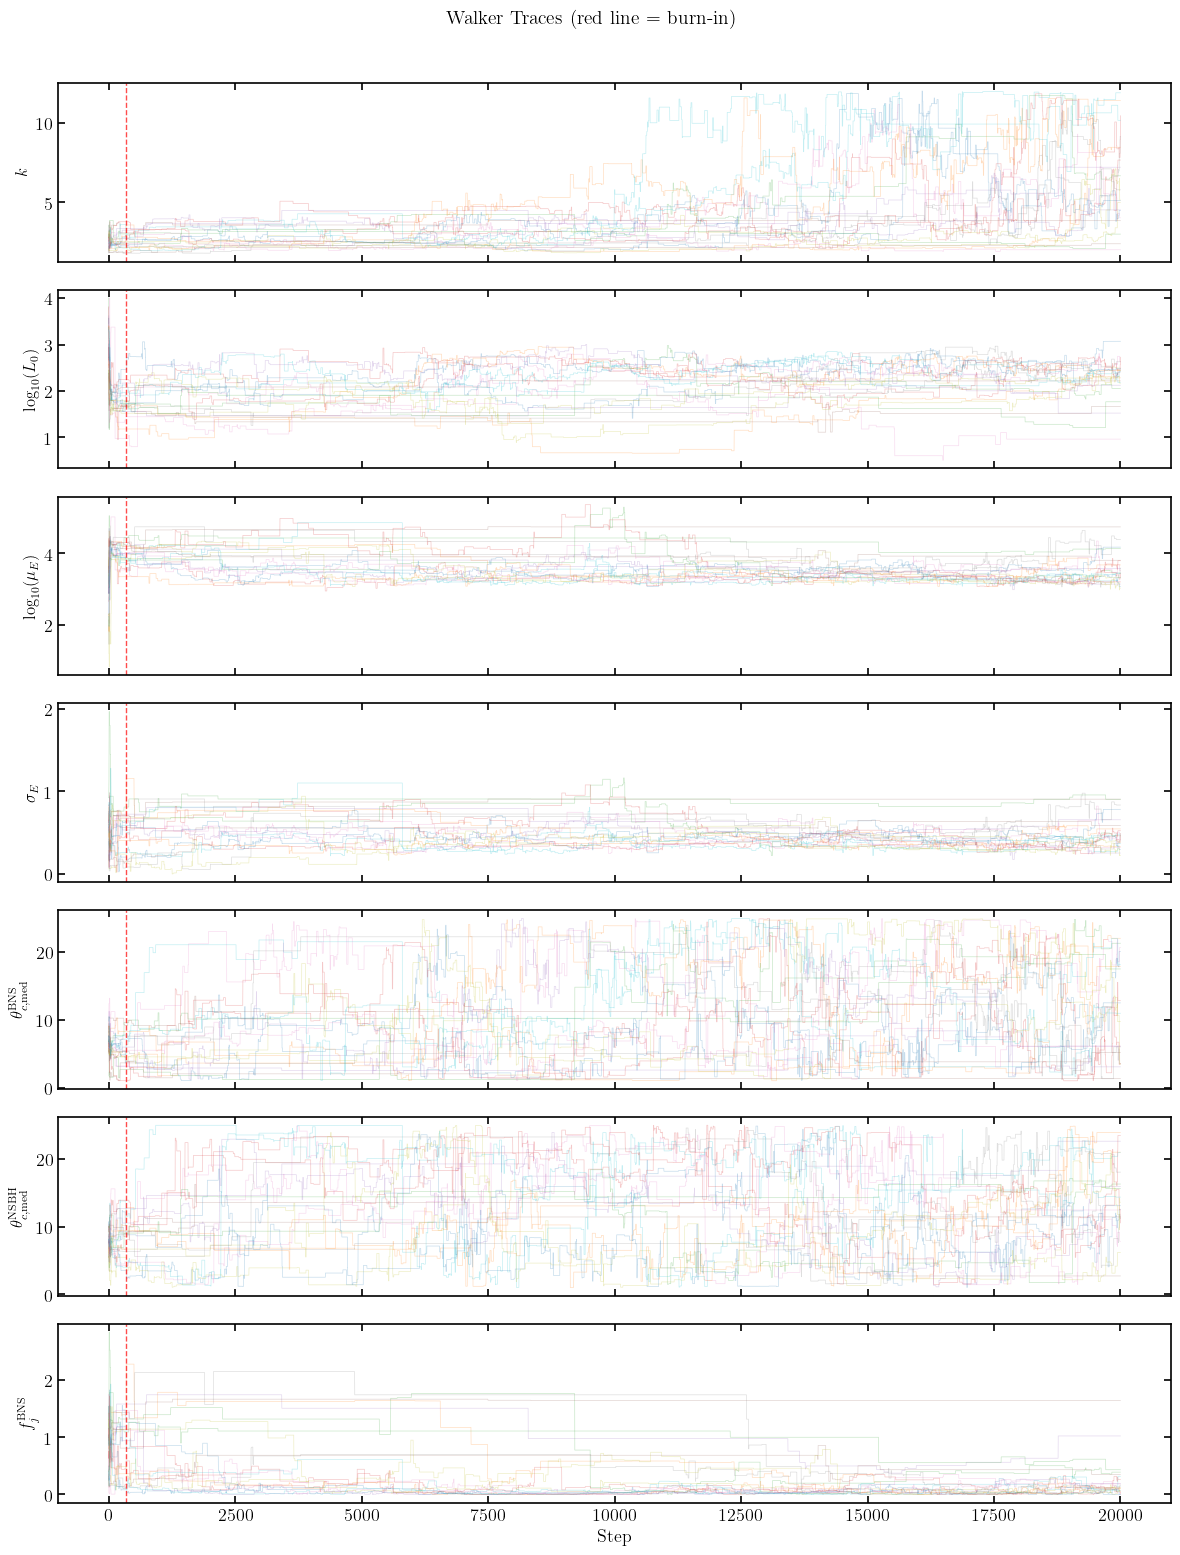

In [81]:
# ── Load backend (can re-run this cell independently) ───────────────────────
backend_combined = emcee.backends.HDFBackend(output_dir / "emcee.h5")

burn_in = N_STEPS // 3
thin    = 15

chain = backend_combined.get_chain(discard=burn_in, thin=thin, flat=False)
flat_samples = backend_combined.get_chain(discard=burn_in, thin=thin, flat=True)

print(f"Total steps: {backend_combined.iteration}")
print(f"After burn-in ({burn_in}) + thin ({thin}): {flat_samples.shape[0]} samples")
print(f"Acceptance fraction: {np.mean(backend_combined.accepted / backend_combined.iteration):.3f}")

# ── Trace plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(N_PARAMS, 1, figsize=(12, 2.2 * N_PARAMS), sharex=True)
full_chain = backend_combined.get_chain(flat=False)  # (n_steps, n_walkers, n_params)

for i, (ax, label) in enumerate(zip(axes, PARAM_NAMES)):
    for w in range(full_chain.shape[1]):
        ax.plot(full_chain[:, w, i], alpha=0.25, lw=0.5)
    ax.set_ylabel(label, fontsize=12)
    ax.axvline(burn_in, color='red', ls='--', lw=1, alpha=0.7)

axes[-1].set_xlabel("Step")
fig.suptitle("Walker Traces (red line = burn-in)", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(output_dir / "trace_plot.pdf", dpi=150, bbox_inches='tight')
plt.show()

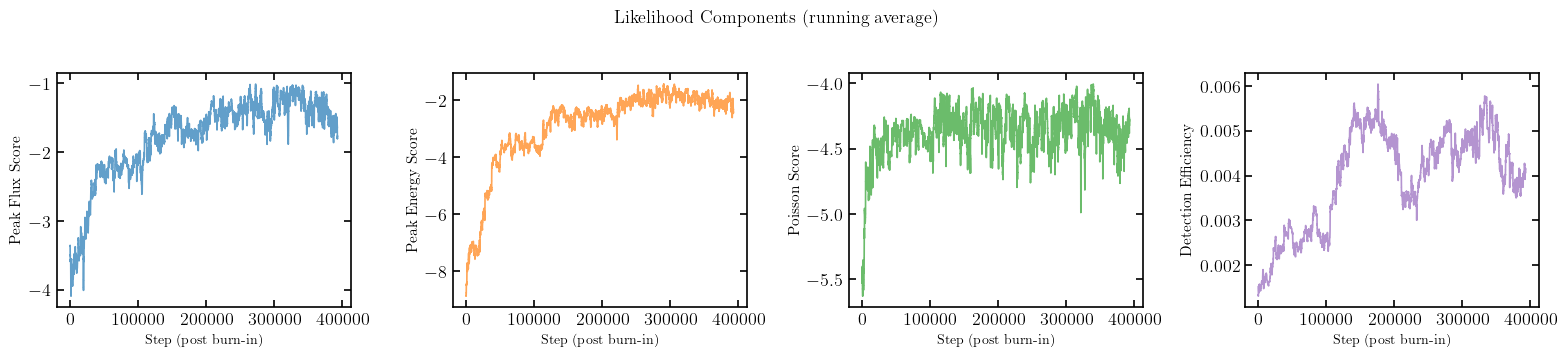

In [82]:
# ── Likelihood component evolution ──────────────────────────────────────────
blobs = backend_combined.get_blobs(discard=burn_in, flat=True)
window = 200

def running_avg(arr, w=window):
    return np.convolve(arr, np.ones(w)/w, mode='valid')

fig, axs = plt.subplots(1, 4, figsize=(16, 3.5))
titles = ['Peak Flux Score', 'Peak Energy Score', 'Poisson Score', 'Detection Efficiency']
colors = plt.cm.tab10(np.linspace(0, 0.4, 4))

for ax, name, title, color in zip(axs, blobs.dtype.names, titles, colors):
    data = running_avg(blobs[name])
    ax.plot(data, color=color, alpha=0.7, lw=1.2)
    ax.set_ylabel(title, fontsize=11)
    ax.set_xlabel("Step (post burn-in)", fontsize=10)

plt.suptitle("Likelihood Components (running average)", fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(output_dir / "likelihood_evolution.pdf", dpi=150, bbox_inches='tight')
plt.show()

## 12. Corner Plot

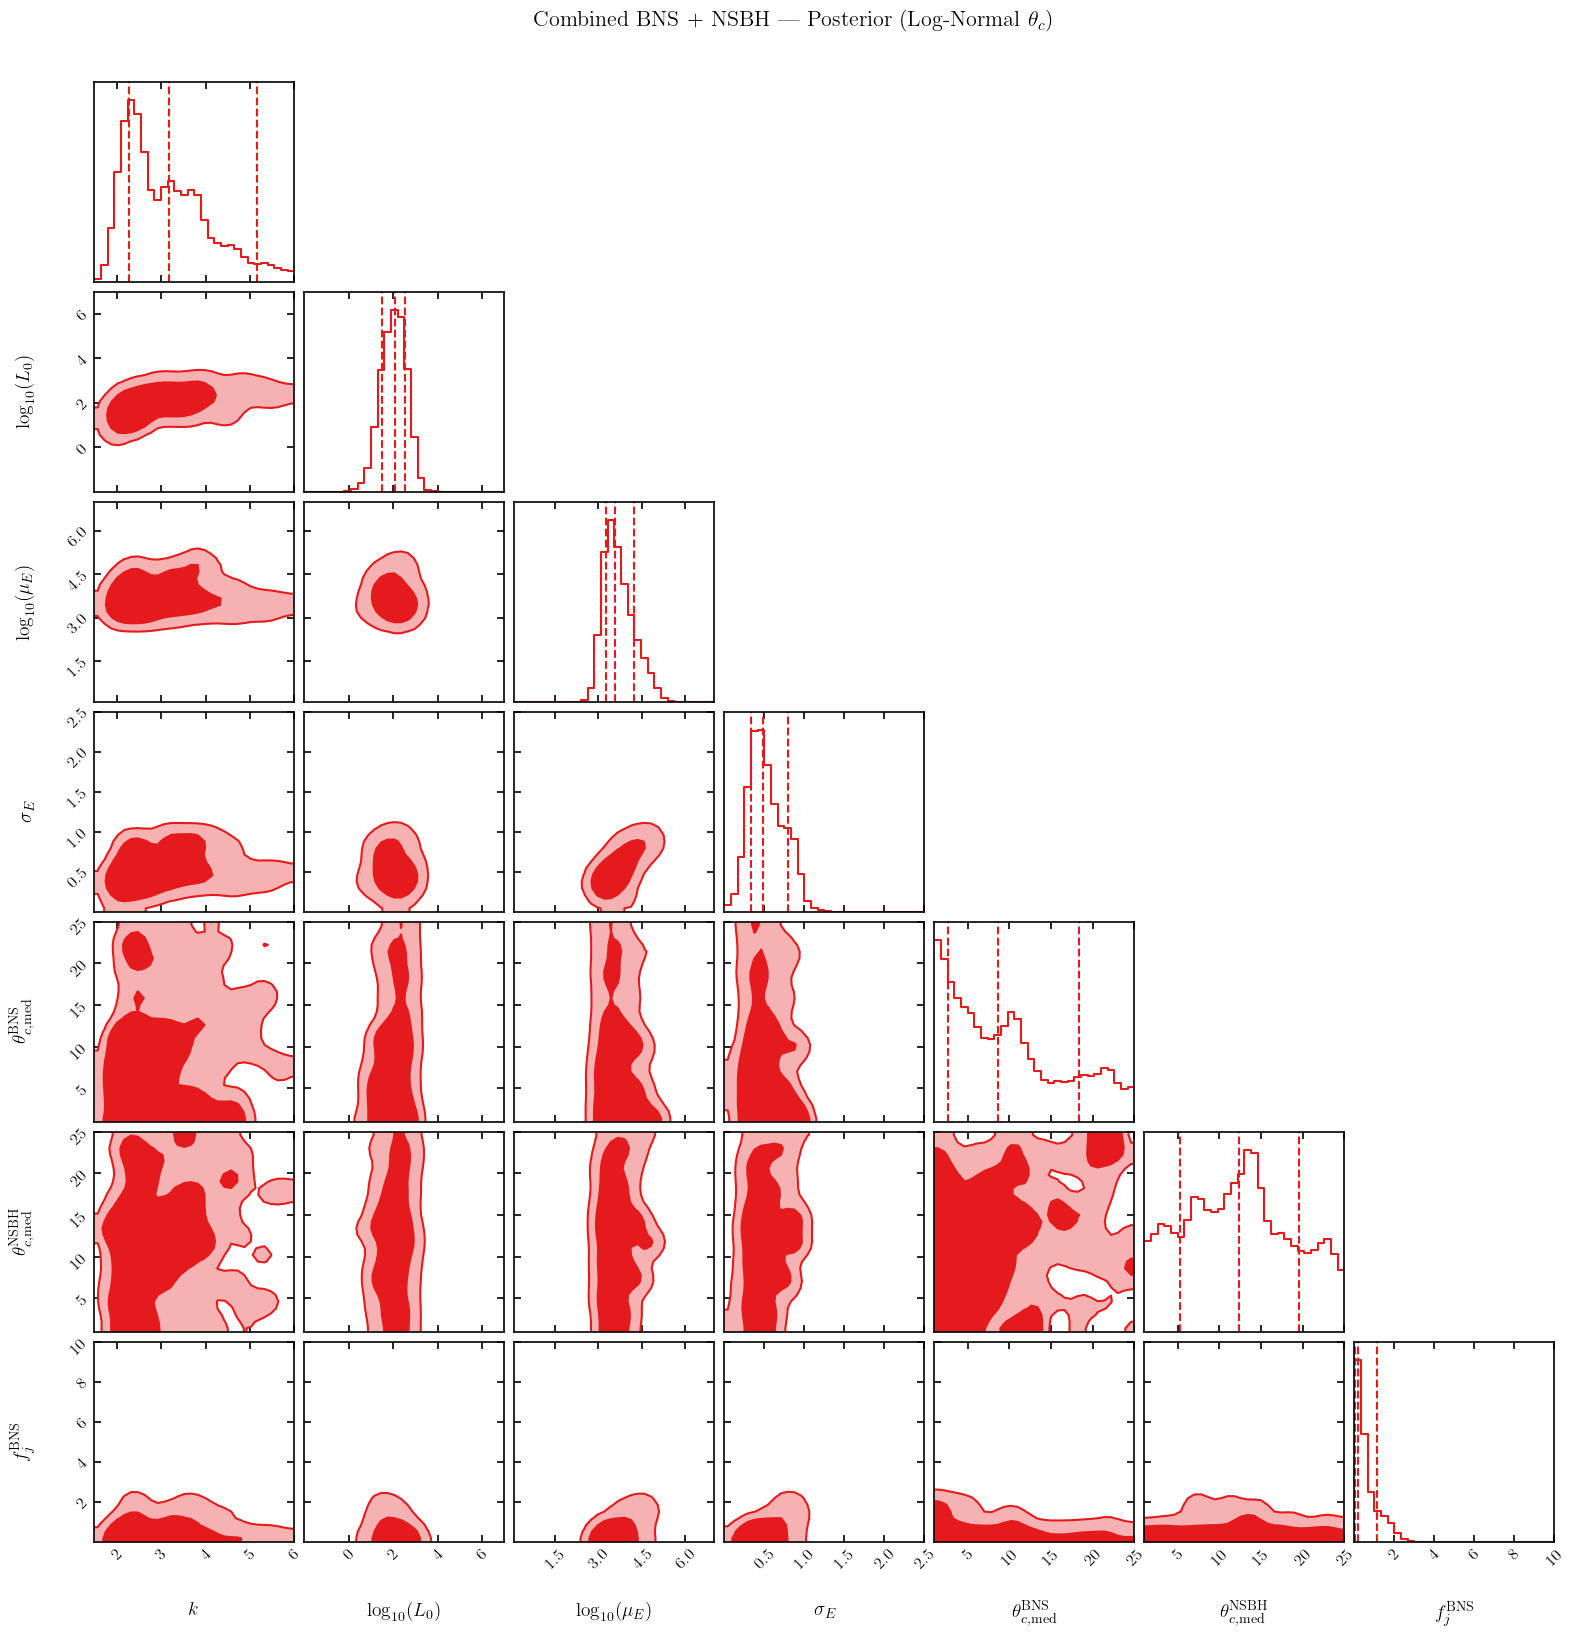


Parameter estimates (median ± 1σ):
                                  $k$  =  3.171  [2.280, 5.155]
                     $\log_{10}(L_0)$  =  2.064  [1.470, 2.530]
                   $\log_{10}(\mu_E)$  =  3.561  [3.261, 4.223]
                           $\sigma_E$  =  0.488  [0.338, 0.793]
  $\theta_{c,\mathrm{med}}^{\mathrm{BNS}}$  =  8.607  [2.647, 18.360]
  $\theta_{c,\mathrm{med}}^{\mathrm{NSBH}}$  =  12.382  [5.317, 19.530]
                 $f_j^{\mathrm{BNS}}$  =  0.181  [0.027, 1.112]


In [83]:
import corner
import matplotlib.colors as mcolors

ranges = [
    (1.5, 6),    # A_index
    (-2, 7),     # L_L0
    (0.1, 7),    # L_mu_E
    (0, 2.5),    # sigma_E
    (1, 25),     # theta_c_med_bns
    (1, 25),     # theta_c_med_nsbh
    (0, 10),     # fj_bns
]

col = [mcolors.to_hex(c) for c in plt.cm.Set1(np.linspace(0, 1, 9))]

fig = corner.corner(
    flat_samples,
    labels=PARAM_NAMES,
    range=ranges,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=False,
    label_kwargs={"fontsize": 14},
    levels=[0.68, 0.95],
    plot_datapoints=False,
    plot_density=False,
    fill_contours=True,
    bins=30,
    smooth=1.5,
    smooth1d=1.0,
    color=col[0],
)

for ax in fig.get_axes():
    ax.grid(False)
    ax.tick_params(labelsize=12)

fig.suptitle("Combined BNS + NSBH — Posterior (Log-Normal $\\theta_c$)", fontsize=16, y=1.02)
fig.savefig(output_dir / "corner_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()

# ── Summary table ───────────────────────────────────────────────────────────
print("\nParameter estimates (median ± 1σ):")
print("=" * 60)
for i, label in enumerate(PARAM_NAMES):
    lo, med, hi = np.percentile(flat_samples[:, i], [16, 50, 84])
    print(f"  {label:>35s}  =  {med:.3f}  [{lo:.3f}, {hi:.3f}]")

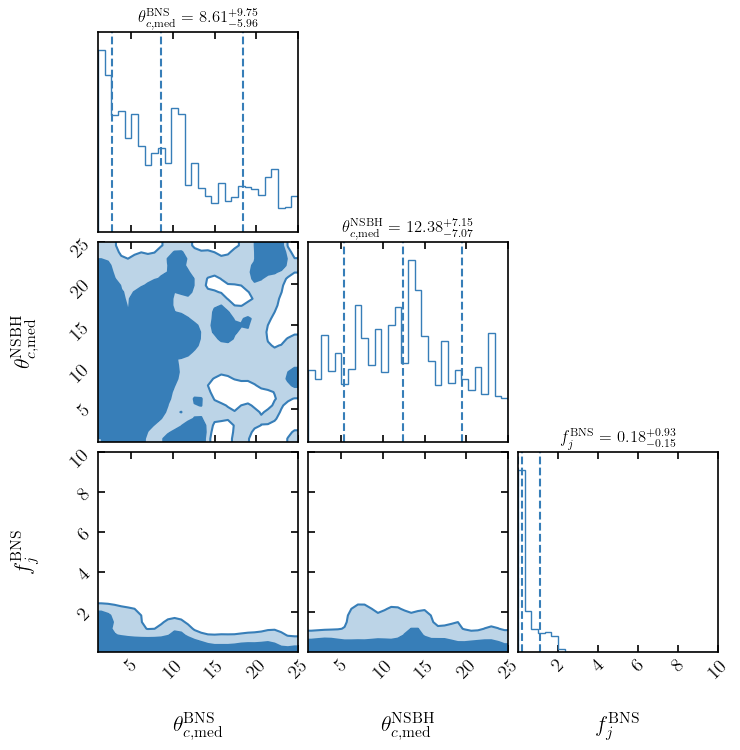

In [84]:
# ── Corner plot: last 3 parameters only (θ_c_bns, θ_c_nsbh, fj_bns) ───────
fig = corner.corner(
    flat_samples[:, 4:],
    labels=PARAM_NAMES[4:],
    range=ranges[4:],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 16},
    levels=[0.68, 0.95],
    plot_datapoints=False,
    plot_density=False,
    fill_contours=True,
    bins=30,
    smooth=1.2,
    color=col[1],
)

for ax in fig.get_axes():
    ax.tick_params(labelsize=14)

fig.savefig(output_dir / "corner_last3.pdf", dpi=300, bbox_inches='tight')
plt.show()

## 13. CDF Comparison & Rate Distribution

Draw posterior samples, simulate combined BNS+NSBH populations, and compare the simulated peak-flux and peak-energy CDFs to the observed Fermi/GBM catalogue.

In [85]:
from src.nsbh.montecarlo import GBM_EFF

n_ppc = 200  # number of posterior draws for PPC
ppc_indices = np.random.default_rng(0).integers(0, len(flat_samples), n_ppc)

pflux_all, epeak_all, rates_all = [], [], []
nsbh_fracs = []

nsbh_distances_ppc = nsbh_data.distances

for idx in ppc_indices:
    theta = flat_samples[idx]
    A_index, L_L0, L_mu_E, sigma_E, theta_c_bns, theta_c_nsbh, fj_bns = theta

    pop = generate_combined_population_tophat(
        theta, bns_params, nsbh_data,
        k_interpolator, geom_eff_interp,
        n_events=10_000, seed=int(idx),
    )
    if pop is None:
        continue

    pflux_all.append(pop["pflux"])
    epeak_all.append(pop["epeak"])
    nsbh_fracs.append(pop["n_nsbh_det"] / max(pop["n_detected"], 1))

    # Predicted rate
    geom_bns  = geom_eff_interp(theta_c_bns)
    geom_nsbh = geom_eff_interp(theta_c_nsbh)
    trig_frac = pop["n_detected"] / 10_000
    rate_bns  = geom_bns  * fj_bns * len(bns_params.z_arr) * GBM_EFF * trig_frac
    rate_nsbh = geom_nsbh * FJ_NSBH_FIXED * len(nsbh_data.z_arr) * GBM_EFF * trig_frac
    rates_all.append(rate_bns + rate_nsbh)

print(f"Generated {len(pflux_all)} PPC populations")

Generated 200 PPC populations


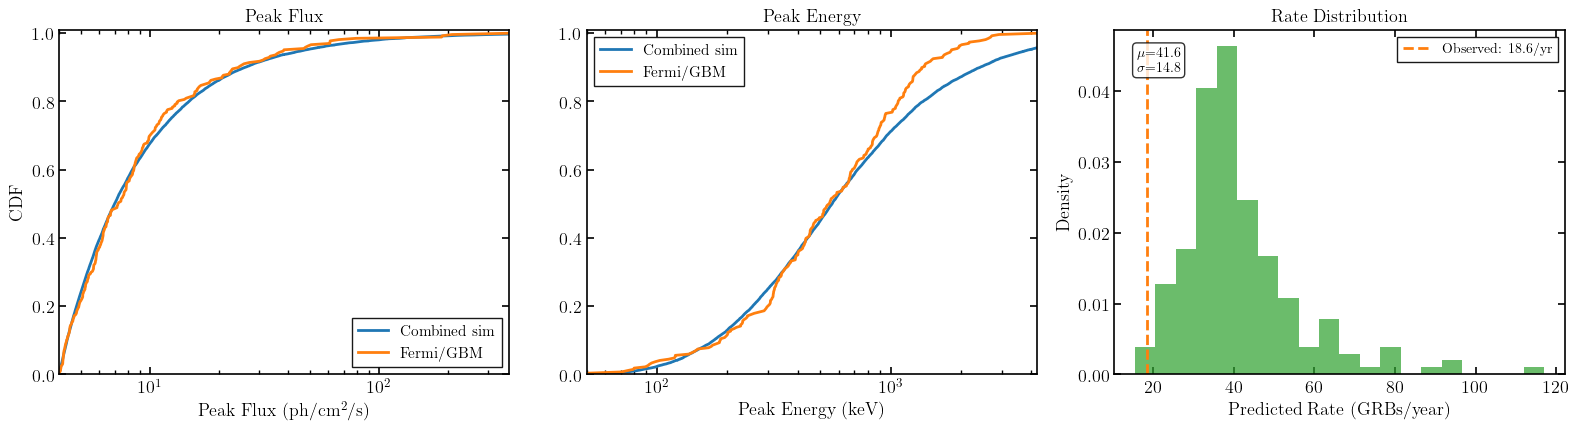

In [86]:
# ── CDF comparison: simulated vs observed ───────────────────────────────────
def ecdf(data):
    x = np.sort(data)
    return x, np.arange(1, len(x) + 1) / len(x)

fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))

# Peak Flux CDF
pflux_sim = np.concatenate(pflux_all)
x_sim, cdf_sim = ecdf(pflux_sim)
x_obs, cdf_obs = ecdf(bns_params.pflux_data)

axs[0].plot(x_sim, cdf_sim, color='#1f77b4', lw=2, label='Combined sim')
axs[0].plot(x_obs, cdf_obs, color='#ff7f0e', lw=2, label='Fermi/GBM')
axs[0].set(xlabel=r'Peak Flux (ph/cm$^2$/s)', ylabel='CDF', xscale='log',
           xlim=(4, bns_params.pflux_data.max()), ylim=(0, 1.01))
axs[0].legend(fontsize=11)
axs[0].set_title("Peak Flux")

# Peak Energy CDF
epeak_sim = np.concatenate(epeak_all)
x_sim_e, cdf_sim_e = ecdf(epeak_sim)
x_obs_e, cdf_obs_e = ecdf(bns_params.epeak_data)

axs[1].plot(x_sim_e, cdf_sim_e, color='#1f77b4', lw=2, label='Combined sim')
axs[1].plot(x_obs_e, cdf_obs_e, color='#ff7f0e', lw=2, label='Fermi/GBM')
axs[1].set(xlabel=r'Peak Energy (keV)', xscale='log',
           xlim=(50, bns_params.epeak_data.max()), ylim=(0, 1.01))
axs[1].legend(fontsize=11)
axs[1].set_title("Peak Energy")

# Rate distribution
axs[2].hist(rates_all, bins=20, alpha=0.7, color='#2ca02c', density=True)
axs[2].axvline(bns_params.yearly_rate, color='#ff7f0e', ls='--', lw=2,
               label=f'Observed: {bns_params.yearly_rate:.1f}/yr')
axs[2].set(xlabel='Predicted Rate (GRBs/year)', ylabel='Density')
axs[2].text(0.05, 0.95,
            f'$\\mu$={np.mean(rates_all):.1f}\n$\\sigma$={np.std(rates_all):.1f}',
            transform=axs[2].transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axs[2].legend(fontsize=10)
axs[2].set_title("Rate Distribution")

plt.tight_layout()
fig.savefig(output_dir / "cdf_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

## 14. NSBH Contribution Analysis

Visualise the posterior distribution of the NSBH fraction of detections and the geometric efficiency comparison between BNS and NSBH.

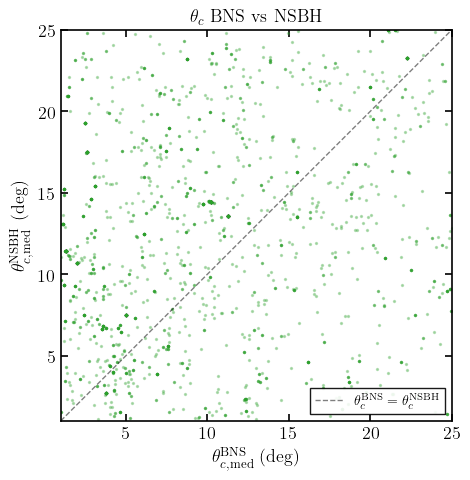

In [87]:
fig, ax = plt.subplots(figsize=(8, 5))

# ── Panel 2: Geometric efficiency posteriors ────────────────────────────────
theta_bns_post  = flat_samples[:, 4]
theta_nsbh_post = flat_samples[:, 5]

geom_bns_post  = np.array([geom_eff_interp(t) for t in theta_bns_post])
geom_nsbh_post = np.array([geom_eff_interp(t) for t in theta_nsbh_post])

# ── Panel 3: θ_c_bns vs θ_c_nsbh scatter ───────────────────────────────────
sub = np.random.default_rng(0).choice(len(flat_samples), min(2000, len(flat_samples)), replace=False)
ax.scatter(flat_samples[sub, 4], flat_samples[sub, 5], s=2, alpha=0.3, c='#2ca02c')
ax.plot([1, 25], [1, 25], 'k--', lw=1, alpha=0.5, label=r'$\theta_c^{\rm BNS} = \theta_c^{\rm NSBH}$')
ax.set_xlabel(r"$\theta_{c,\mathrm{med}}^{\mathrm{BNS}}$ (deg)")
ax.set_ylabel(r"$\theta_{c,\mathrm{med}}^{\mathrm{NSBH}}$ (deg)")
ax.set_title(r"$\theta_c$ BNS vs NSBH")
ax.set_xlim(1, 25)
ax.set_ylim(1, 25)
ax.set_aspect('equal')
ax.legend(fontsize=10)

plt.tight_layout()
fig.savefig(output_dir / "nsbh_analysis.pdf", dpi=300, bbox_inches='tight')
plt.show()